# MCMC Diagnostics in R

## Overview

MCMC diagnostics confirm that the sampler has explored the posterior distribution adequately. A converged chain has: (1) mixed well across the parameter space, (2) reached its stationary distribution, and (3) produced enough effective samples for reliable inference.

**Core diagnostics:**

| Diagnostic | What it checks | Threshold |
|---|---|---|
| **Trace plot** | Visual: chains mixing and overlapping | Caterpillar shape; no drift or sticking |
| **R-hat** ($\hat{R}$) | Between-chain vs. within-chain variance | < 1.01 (strict); < 1.05 (lenient) |
| **Bulk ESS** | Effective samples in the centre of the posterior | > 400 per parameter; > 100 × n_chains |
| **Tail ESS** | Effective samples in the tails (for CI reliability) | > 400 per parameter |
| **Energy / BFMI** | HMC-specific: geometry of the posterior | BFMI > 0.3 |
| **Divergences** | HMC-specific: sampler got lost | 0 divergences after warmup |
| **Posterior predictive check** | Model adequacy, not just sampler adequacy | Simulated data resembles observed |

**Important distinction:** Convergence diagnostics confirm the *sampler* worked. Posterior predictive checks confirm the *model* is adequate. Both are necessary.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(brms)
library(bayesplot)   # mcmc_trace(), mcmc_acf(), mcmc_rhat(), ppc_*
library(posterior)   # rhat(), ess_bulk(), ess_tail() — modern interface
library(patchwork)

set.seed(42)

# ── Fit a well-behaved model ──────────────────────────────────────────────────
n <- 100
diag_data <- tibble(
  x = rnorm(n),
  y = 5 + 2*x + rnorm(n)
)

m_good <- brm(
  y ~ x, data=diag_data, family=gaussian(),
  prior=c(prior(normal(5,5), class=Intercept),
          prior(normal(0,3),  class=b),
          prior(exponential(1), class=sigma)),
  chains=4, iter=3000, warmup=1000, cores=4, seed=42, silent=2
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'brms' was built under R version 4.4.3"
Loading required package: Rcpp

Loading 'brms' package (version 2.2

---

## Trace Plots

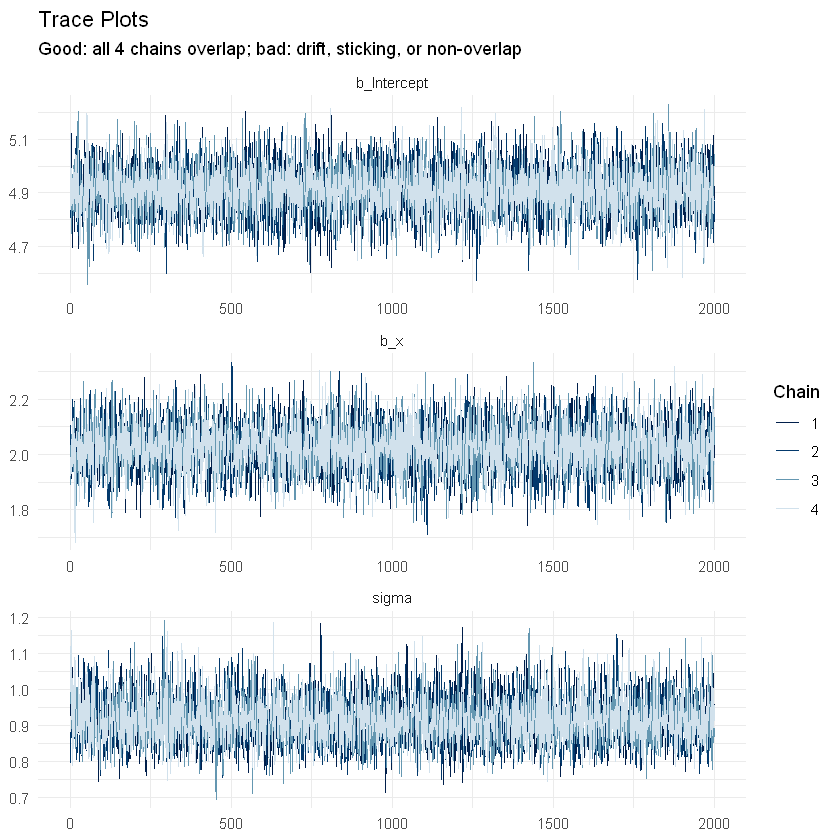

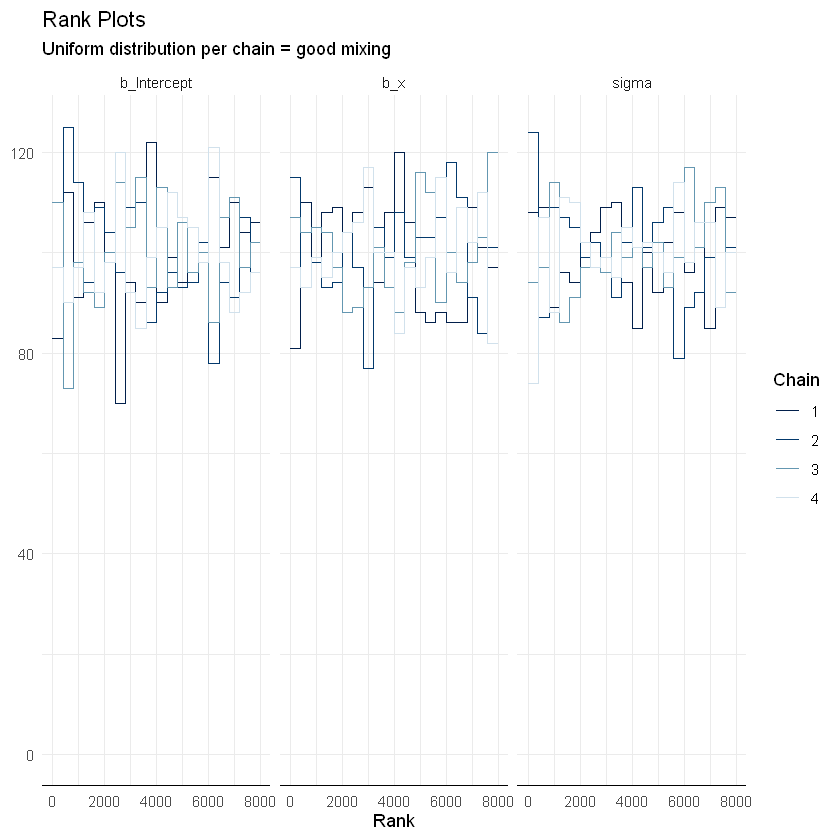

In [2]:
# Extract posterior draws as array (chains × iterations × parameters)
draws_array <- as.array(m_good)
params      <- c("b_Intercept","b_x","sigma")

# ── Trace plot ────────────────────────────────────────────────────────────────
bayesplot::mcmc_trace(draws_array, pars=params,
                      facet_args=list(ncol=1)) +
  labs(title="Trace Plots",
       subtitle="Good: all 4 chains overlap; bad: drift, sticking, or non-overlap") +
  theme_minimal()

# ── Rank plot (alternative to trace — better for detecting non-mixing) ────────
bayesplot::mcmc_rank_overlay(draws_array, pars=params) +
  labs(title="Rank Plots",
       subtitle="Uniform distribution per chain = good mixing") +
  theme_minimal()

# Signs of a BAD trace plot:
# - Slow drift upward or downward (non-stationarity)
# - Long horizontal runs (getting stuck — high autocorrelation)
# - Chains in different locations (non-convergence)
# - Sudden jumps without return (bimodal posterior)

---

## R-hat and Effective Sample Size

R-hat values:
b_Intercept         b_x       sigma   Intercept      lprior        lp__ 
     1.0011      1.0006      1.0002      1.0012      1.0002      1.0002 

Max R-hat: 1.0012  (must be < 1.01)

ESS ratio (should be > 0.1):
b_Intercept         b_x       sigma   Intercept      lprior        lp__ 
      0.704       0.704       0.694       0.704       0.687       0.512 

Total draws: 8000
Min effective draws: 4099  (must be > 400)


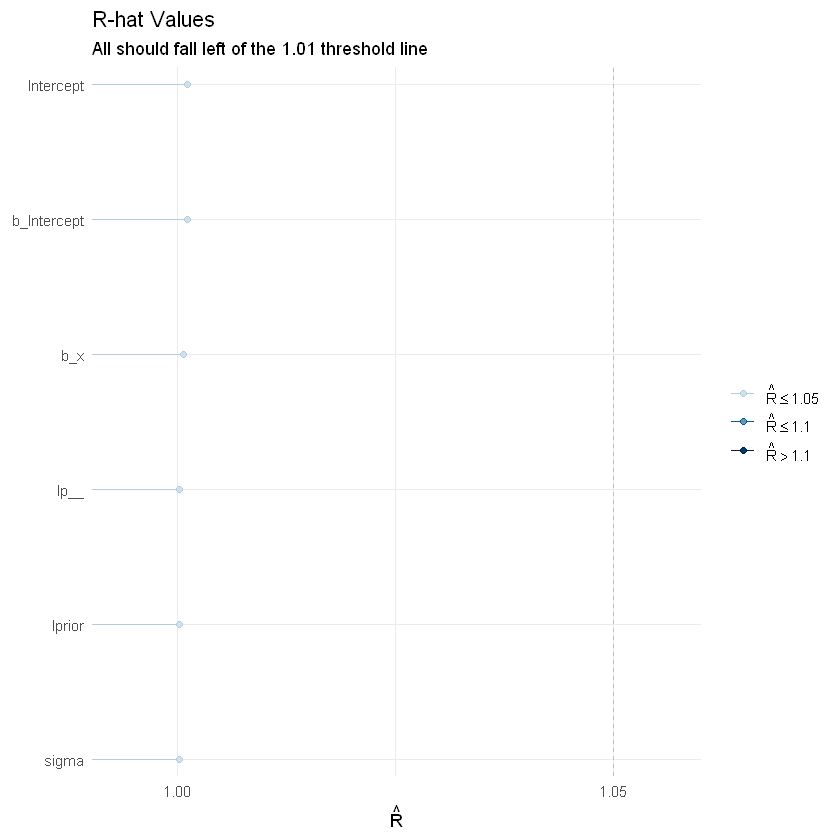

In [3]:
# ── R-hat: between-chain / within-chain variance ratio ───────────────────────
# R-hat = 1.00: chains identical (converged)
# R-hat > 1.01: chains different — do not use results

rhat_vals <- brms::rhat(m_good)
cat(sprintf("R-hat values:\n"))
print(round(rhat_vals, 4))
cat(sprintf("\nMax R-hat: %.4f  (must be < 1.01)\n", max(rhat_vals, na.rm=TRUE)))

# Visualise
bayesplot::mcmc_rhat(rhat_vals) +
  labs(title="R-hat Values",
       subtitle="All should fall left of the 1.01 threshold line") +
  theme_minimal()

# ── Effective Sample Size ─────────────────────────────────────────────────────
# ESS is less than raw iterations because MCMC samples are autocorrelated
# Bulk ESS: reliability of posterior mean and bulk quantiles
# Tail ESS: reliability of extreme quantiles (credible interval bounds)

neff  <- brms::neff_ratio(m_good)  # ESS / total draws
cat(sprintf("\nESS ratio (should be > 0.1):\n"))
print(round(neff, 3))

# Total draws = n_chains × (n_iter - n_warmup) = 4 × 2000 = 8000
total_draws <- 4 * (3000 - 1000)
cat(sprintf("\nTotal draws: %d\n", total_draws))
cat(sprintf("Min effective draws: %.0f  (must be > 400)\n",
            min(neff, na.rm=TRUE) * total_draws))

---

## Autocorrelation and HMC-Specific Diagnostics

Post-warmup divergences: 0  (must be 0)


NULL


BFMI per chain: 1.133, 1.092, 1.019, 1.003  (should be > 0.3)


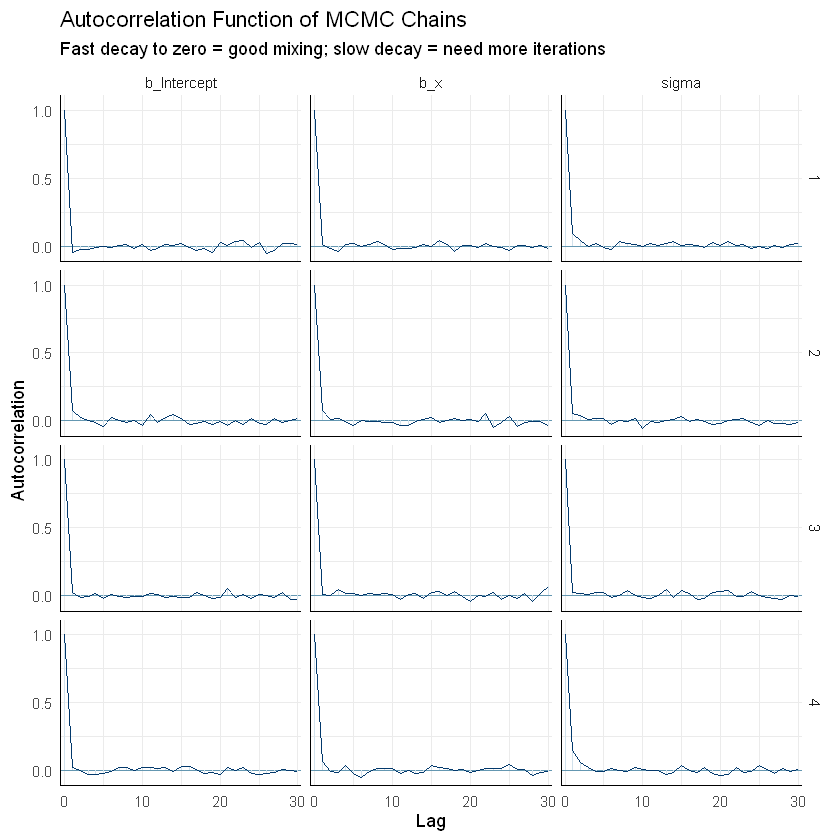

In [4]:
# ── ACF plot: how quickly autocorrelation decays ─────────────────────────────
bayesplot::mcmc_acf(draws_array, pars=params, lags=30) +
  labs(title="Autocorrelation Function of MCMC Chains",
       subtitle="Fast decay to zero = good mixing; slow decay = need more iterations") +
  theme_minimal()

# ── HMC-specific: divergences ─────────────────────────────────────────────────
# Divergences occur when the sampler's step size is too large and it
# flies off the posterior geometry. Even 1 divergence can indicate bias.
nuts_params <- brms::nuts_params(m_good)
n_divergent <- sum(nuts_params$Value[nuts_params$Parameter=="divergent__"] == 1)
cat(sprintf("Post-warmup divergences: %d  (must be 0)\n", n_divergent))

# ── Pairs plot: detect funnel geometries ──────────────────────────────────────
# Divergent transitions (if any) appear in a specific region of parameter space
bayesplot::mcmc_pairs(
  draws_array,
  pars       = c("b_Intercept","b_x","sigma"),
  off_diag_args = list(size=0.4, alpha=0.4)
) +
  labs(title="Pairs Plot",
       subtitle="Funnel shapes or points in corners indicate geometry issues")

# ── BFMI (Bayesian Fraction of Missing Information) ───────────────────────────
bfmi <- sapply(1:4, function(c) {
  e <- nuts_params %>% filter(Chain==c, Parameter=="energy__") %>% pull(Value)
  var(diff(e)) / var(e)
})
cat(sprintf("\nBFMI per chain: %s  (should be > 0.3)\n",
            paste(round(bfmi, 3), collapse=", ")))

---

## Posterior Predictive Checks

Note: in most cases the default test statistic 'mean' is too weak to detect anything of interest.

Note: in most cases the default test statistic 'mean' is too weak to detect anything of interest.

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the bayesplot package.
  Please report the issue at <https://github.com/stan-dev/bayesplot/issues/>."
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


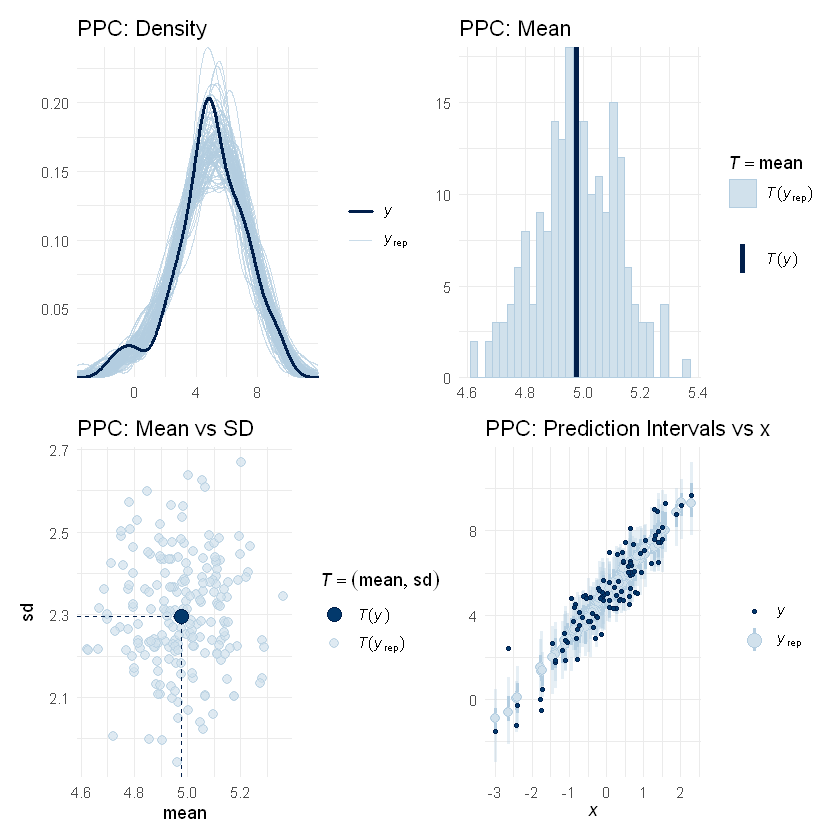

In [5]:
# Draw replicated datasets from the fitted model
y_rep <- posterior_predict(m_good, ndraws=200)

# ── Density overlay ───────────────────────────────────────────────────────────
p1 <- bayesplot::ppc_dens_overlay(diag_data$y, y_rep[1:100,]) +
  labs(title="PPC: Density") + theme_minimal()

# ── Test statistics: mean, SD, min, max ───────────────────────────────────────
p2 <- bayesplot::ppc_stat(diag_data$y, y_rep, stat="mean") +
  labs(title="PPC: Mean") + theme_minimal()

p3 <- bayesplot::ppc_stat_2d(diag_data$y, y_rep,
                              stat=c("mean","sd")) +
  labs(title="PPC: Mean vs SD") + theme_minimal()

# ── Intervals: point estimates and uncertainty ────────────────────────────────
p4 <- bayesplot::ppc_intervals(
  diag_data$y, y_rep[1:50,],
  x=diag_data$x
) +
  labs(title="PPC: Prediction Intervals vs x") + theme_minimal()

(p1 | p2) / (p3 | p4)

# What to look for:
# - Density: observed curve should fall within the envelope of replicated curves
# - Test stats: observed statistic (dark line) should fall in the bulk of the
#   histogram of replicated statistics
# - If observed is in the tail: model is missing important structure

---

## Diagnosing and Fixing a Poorly Mixing Chain

In [6]:
# ── Common causes of poor mixing and fixes ────────────────────────────────────

# 1. High posterior correlation between parameters
#    Fix: centre/scale predictors; use non-centred parameterisation in hierarchical models

# 2. Divergences in hierarchical models — the "funnel" problem
#    Fix: non-centred parameterisation (brms does this automatically when possible)
#    Fix: increase adapt_delta (default 0.80; try 0.95-0.99)
m_adapt <- brm(
  y ~ x, data=diag_data, family=gaussian(),
  prior=c(prior(normal(5,5), class=Intercept),
          prior(normal(0,3),  class=b),
          prior(exponential(1), class=sigma)),
  chains=4, iter=4000, warmup=2000, cores=4, seed=42, silent=2,
  control=list(
    adapt_delta   = 0.95,   # higher = smaller step size = fewer divergences
    max_treedepth = 12      # default 10; increase if hitting max treedepth warnings
  )
)

# 3. Too few iterations
#    Fix: increase iter; or warm up longer (warmup ~ 50% of total)

# 4. Multimodal posterior
#    Fix: check model specification; consider whether the model is identifiable

cat("Controls for common mixing problems shown above.\n")

Controls for common mixing problems shown above.


---

## Common Pitfalls

**1. Reporting results without checking any diagnostics**  
Always check R-hat, ESS, trace plots, and divergence count before reporting any posterior summaries. A non-converged chain gives wrong answers with no warning in the output table.

**2. Treating R-hat < 1.1 as the convergence standard**  
The older threshold of R-hat < 1.1 is too lenient. The current standard (Vehtari et al. 2021) is R-hat < 1.01, using the improved split-R-hat algorithm implemented in `posterior::rhat()` and recent `brms`.

**3. Discarding or thinning samples to remove autocorrelation**  
Autocorrelated samples are still valid samples — they just represent fewer effective draws. Thinning wastes information. Instead, run more iterations to accumulate enough ESS. Aim for bulk ESS > 400 per parameter, not a target autocorrelation.

**4. Ignoring divergences**  
Even a single post-warmup divergence is a red flag. Divergences indicate regions of the posterior that the sampler could not explore, leading to biased estimates. Do not dismiss them as acceptable — increase `adapt_delta` or reparameterise.

**5. Confusing MCMC diagnostics with model diagnostics**  
Good R-hat and zero divergences confirm the sampler converged, not that the model is correct. A perfectly converged chain from a misspecified model gives you the exact wrong answer. Always also run posterior predictive checks.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*